In [1]:
import time
from typing import List
import itertools
import numpy as np
from tqdm.auto import tqdm
from scipy.integrate import odeint
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
import torchode

from ftnode.node import (FeluSigmoidMLP, GeluSigmoidMLP, FTNODE)

from sklearn.cluster import KMeans
from scipy.optimize import root as sp_root

import torch
import torch.nn as nn
device='cpu'

from ftnode.utils import set_global_seed

seed = 1234
set_global_seed(seed = seed)

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
model_path = "../best_model-20-20-20.pth"

f = FeluSigmoidMLP(
    dims = [2,20,20,20,2],
    lower_bound = -10,
    upper_bound =-0.1
)

g = GeluSigmoidMLP(
    dims = [6,20,20,20,2],
    lower_bound = -1,
    upper_bound = 8
)

model = FTNODE(f,g)

model.load_state_dict(torch.load(model_path))
model.eval() #

f = model.f
g = model.g

f.eval()
g.eval()


GeluSigmoidMLP(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=2, bias=True)
    )
  )
)

In [3]:
def genetic_toggle_switch(state, t, alpha1, alpha2, beta, gamma):
    """
    Computes derivatives for Equation 27 (Li & Lin, 2013).
    """
    x1, x2 = state
    # Note: In this symmetric simulation, alpha1=alpha2 and beta=gamma
    dx1dt = -x1 + alpha1 / (1 + x2**beta)
    dx2dt = -x2 + alpha2 / (1 + x1**gamma)
    return [dx1dt, dx2dt]

# composite figure

In [4]:
Us = [
    [2.1,2,2.5,5],
    [4,4,4,4],
    # [5,5,5,5],
    [3,4,1,1],
    [1.2,1.5,1.1,4],
    
]
n_guesses = 6

Vs = []
model_roots = []
true_roots = []

x_vals_yup = np.linspace(.01, 5, 501)
y_vals_yup = np.linspace(.01, 5, 501)

X1s, X2s= np.meshgrid(x_vals_yup,y_vals_yup)

for u in tqdm(Us):
    ########################
    # calculate true roots
    ########################
    X12s = np.vstack((X1s.reshape(-1),X2s.reshape(-1))).T

    dX1, dX2 = genetic_toggle_switch([X12s[:,0],X12s[:,1]],t=None,alpha1=u[0],alpha2=u[1],beta=u[2],gamma=u[3])

    def objective(x):
        return np.array(genetic_toggle_switch(
            state=x,t=None,alpha1=u[0],alpha2=u[1],beta=u[2],gamma=u[3]
        ))

    err = np.sqrt((dX1**2 + dX2**2))
    percentage_cutoff = 10
    thresh = np.percentile(err,percentage_cutoff)
    canidate_indices = np.where(err < thresh)

    kmeans = KMeans(n_clusters=n_guesses,random_state=67)

    kmeans.fit(X12s[canidate_indices])

    initial_guesses = kmeans.cluster_centers_

    roots = []
        
        # 4. Refine using Scipy
        # We iterate through guesses, but you can optimize this by clustering guesses first
    for guess in initial_guesses:
        sol = sp_root(objective, guess)
        if sol.success:
            roots.append(sol.x)

    roots = np.array(roots)
    true_roots_i = []

    for r in roots:
        # If this root is not close to any root we've already saved
        if not any(np.allclose(r, existing, atol=1e-12) for existing in true_roots_i):
            true_roots_i.append(r)
    
    true_roots.append(true_roots_i)

    ########################
    # Calculate Model Roots
    ########################
    X12s = torch.tensor(X12s,dtype=torch.float32)

    U = torch.tensor(
        [u],dtype=torch.float32
    ).expand(len(X12s),-1)


    with torch.no_grad():
        err = torch.linalg.norm(X12s - g(X12s,U),axis=1)

    def objective(x):
        x_torch = torch.tensor(x,dtype=torch.float32)
        u_torch = torch.tensor(u,dtype=torch.float32)
        with torch.no_grad():
            g_out = g(x_torch,u_torch)
        diff = x_torch - g_out
        return diff.numpy()

    percentage_cutoff = 0.2
    thresh = np.percentile(err,percentage_cutoff)
    canidate_indices = np.where(err < thresh)

    
    kmeans = KMeans(n_clusters=n_guesses,random_state=67)
    kmeans.fit(X12s[canidate_indices].numpy())

    initial_guesses = kmeans.cluster_centers_

    roots = []
        
        # 4. Refine using Scipy
        # We iterate through guesses, but you can optimize this by clustering guesses first
    for guess in initial_guesses:
        sol = sp_root(objective, guess)
        if sol.success:
            roots.append(sol.x)

    roots = np.array(roots)

    model_roots_i = []

    for r in roots:
        # If this root is not close to any root we've already saved
        if not any(np.allclose(r, existing, atol=1e-12) for existing in model_roots_i):
            model_roots_i.append(r)
    
    model_roots.append(model_roots_i)

    # compute V
    U = torch.tensor([u],dtype=torch.float32).expand(len(X12s),-1)

    with torch.no_grad():
        g_out = g(X12s,U)

    G1 = g_out[:,0].reshape(X1s.shape)
    G2 = g_out[:,1].reshape(X1s.shape)

    G1.max(), G1.min(), G2.max(), G2.min()

    with torch.no_grad():
        V = 1/2*torch.sum((X12s - g(X12s,U))**2,axis=1)

    V = V.numpy().reshape(X1s.shape)
    Vs.append(V)
    



  0%|          | 0/4 [00:00<?, ?it/s]

/var/folders/9x/8bf0hckd1b122g3zlj_z9c1w0000gp/T/ipykernel_4829/2751216509.py:7: RuntimeWarning: invalid value encountered in scalar power
  dx1dt = -x1 + alpha1 / (1 + x2**beta)


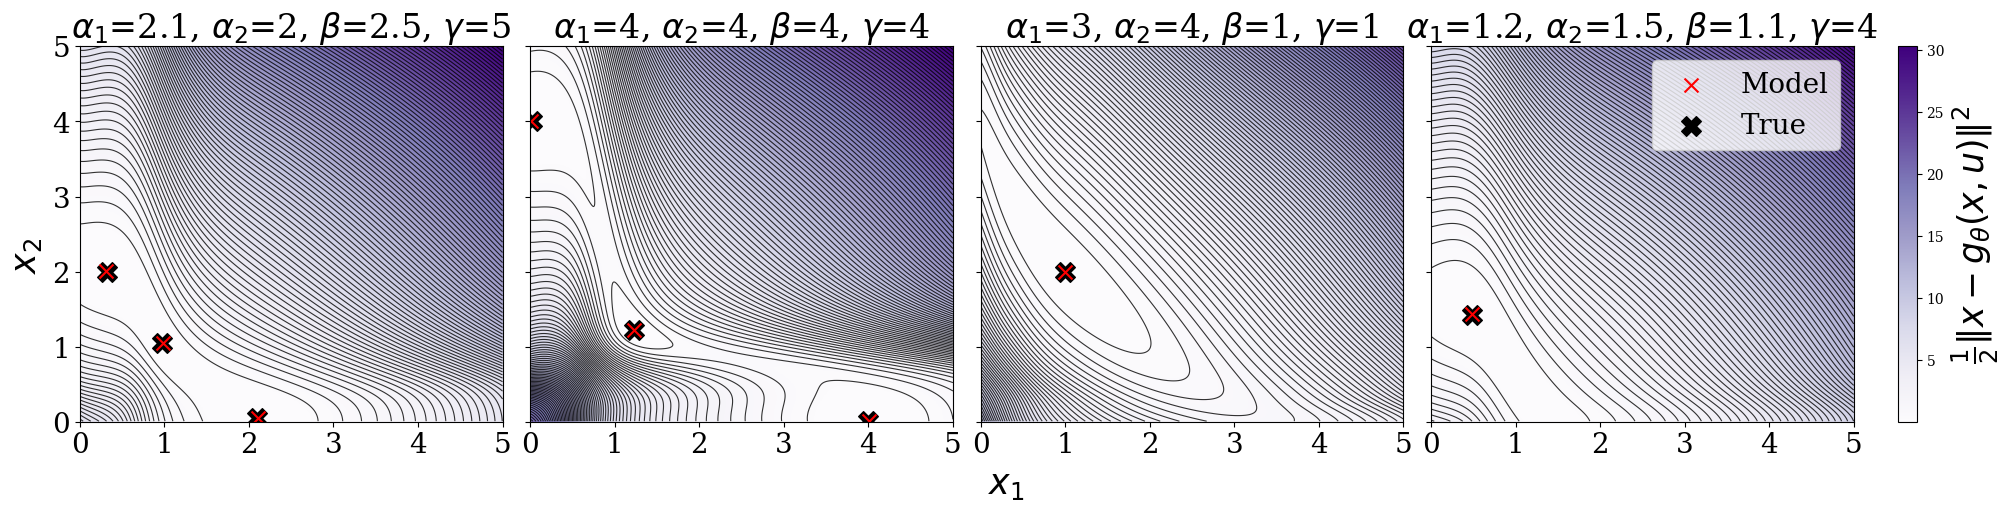

In [5]:
all_V = np.concatenate([v.flatten() for v in Vs])
vmin, vmax = all_V.min(), all_V.max()

fig, axs = plt.subplots(1, len(Us), figsize=(20,5), 
                        sharey=True, sharex=True, constrained_layout=True)

axs = axs.flatten()

heatmap = None 

for idx, ax in enumerate(axs):
    V = Vs[idx]
    model_roots_i = model_roots[idx]
    true_roots_i = true_roots[idx]

    heatmap = ax.pcolormesh(X1s, X2s, V, shading='auto', 
                            cmap='Purples', vmin=vmin, vmax=vmax)

    # Level sets
    cs = ax.contour(X1s, X2s, V, colors='k', linewidths=0.8, levels=100, alpha=0.8)

    for flag, root in enumerate(model_roots_i):
        label = None
        if flag == 0:
            label = 'Model'
        ax.scatter(root[0], root[1], marker='x', c='red', zorder=2,label=label,s=100)

    for flag, root in enumerate(true_roots_i):
        label = None
        if flag == 0:
            label = 'True'
        ax.scatter(root[0], root[1], marker='X', c='black', zorder=1, s=200,label=label)

    u = Us[idx]
    ax.set_title(
        fr"$\alpha_1$={u[0]}, $\alpha_2$={u[1]}, " 
        rf"$\beta$={u[2]}, $\gamma$={u[3]}",
        fontsize=24
    )
    
    ax.set_xlim(left=0)
    if idx == len(axs)-1:
        ax.legend(loc='upper right',fontsize=20)
    

    ax.set_ylim(0,5)
    ax.set_xlim(0,5)

for ax in axs:
    ax.tick_params(axis='both', which='major',labelsize=20)



cbar = fig.colorbar(heatmap, ax=axs, location='right', fraction=0.02, pad=0.02)
cbar.set_label(r"$\frac{1}{2}\|x - g_\theta(x,u) \|^2$", fontsize=25) # Optional label

fig.supxlabel(r"$x_1$", fontsize=25)
fig.supylabel(r"$x_2$", fontsize=25)


plt.savefig("toggle-control-landscape.png")
plt.show()